# Data Extraction

I went to psx.com.pk website and went to their 'Historical Data' tab on the left hand side of their homepage. I chose Karachi Electrics Limited Stock Exchange data for my project. Data starting from Jan 2021 to May 2025 was gathered and put into an excel file. I named this excel file as: "KEL 2021 - 2025 Stock Rate Data.xlsx"

## Data loading

### Subtask:
I loaded the "KEL 2021 - 2025 Stock Rate Data.xlsx" file into a pandas DataFrame.


**Reasoning**:
Load the excel file into a pandas DataFrame and display the first 5 rows.



In [4]:
import pandas as pd

try:
    df = pd.read_excel('KEL 2021 - 2025 Stock Rate Data.xlsx')
    display(df.head())
except FileNotFoundError:
    print("Error: 'KEL 2021 - 2025 Stock Rate Data.xlsx' not found.")
except Exception as e:
    print(f"An error occurred: {e}")

,DATE,OPEN,HIGH,LOW,CLOSE,VOLUME
0,2025-05-27,6.15,6.15,5.66,5.89,267623259
1,2025-05-26,5.72,5.72,5.46,5.72,246932360
2,2025-05-23,4.73,4.75,4.65,4.72,10030569
3,2025-05-22,4.80,4.89,4.66,4.71,42770156
4,2025-05-21,4.44,4.83,4.38,4.75,103655617


In [3]:
from google.colab import files

uploaded = files.upload()

Saving KEL 2021 - 2025 Stock Rate Data.xlsx to KEL 2021 - 2025 Stock Rate Data.xlsx


## Data exploration

### Subtask:
Explore the loaded DataFrame (`df`) to understand its structure and the characteristics of the stock data.


**Reasoning**:
Explore the DataFrame to understand its structure, data types, missing values, and descriptive statistics. Convert the 'DATE' column to datetime if necessary and check its frequency.



In [ ]:
# Check the shape of the DataFrame
print("Shape of the DataFrame:", df.shape)

# Examine the data types of each column
print("\nData types of each column:\n", df.dtypes)

# Identify missing values
print("\nMissing values per column:\n", df.isnull().sum())

# Calculate descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:\n", df.describe())

# Convert 'DATE' column to datetime if it's not already
if not pd.api.types.is_datetime64_any_dtype(df['DATE']):
    df['DATE'] = pd.to_datetime(df['DATE'])
    print("\n'DATE' column converted to datetime.")

# Check the frequency of dates
print("\nDate frequency:\n", df['DATE'].diff().value_counts())

# Display first few and last few rows for visual inspection
print("\nFirst few rows:\n", df.head())
print("\nLast few rows:\n", df.tail())

Shape of the DataFrame: (1082, 6)

Data types of each column:
 DATE      datetime64[ns]
OPEN             float64
HIGH             float64
LOW              float64
CLOSE            float64
VOLUME             int64
dtype: object

Missing values per column:
 DATE      0
OPEN      0
HIGH      0
LOW       0
CLOSE     0
VOLUME    0
dtype: int64

Descriptive statistics for numerical columns:
                                 DATE         OPEN         HIGH          LOW  \
count                           1082  1082.000000  1082.000000  1082.000000   
mean   2023-03-17 09:28:16.857671168     3.576340     3.655323     3.491830   
min              2021-01-01 00:00:00     1.600000     1.610000     1.550000   
25%              2022-02-09 06:00:00     2.850000     2.890000     2.802500   
50%              2023-03-11 12:00:00     3.550000     3.625000     3.480000   
75%              2024-04-21 06:00:00     4.380000     4.487500     4.267500   
max              2025-05-27 00:00:00     6.510000     6.59

## Data analysis

### Subtask:
Analyze the stock rate data for trends and patterns.


**Reasoning**:
Analyze trends in stock prices over time, investigate the relationship between trading volume and stock prices, and analyze the distribution of daily price changes.



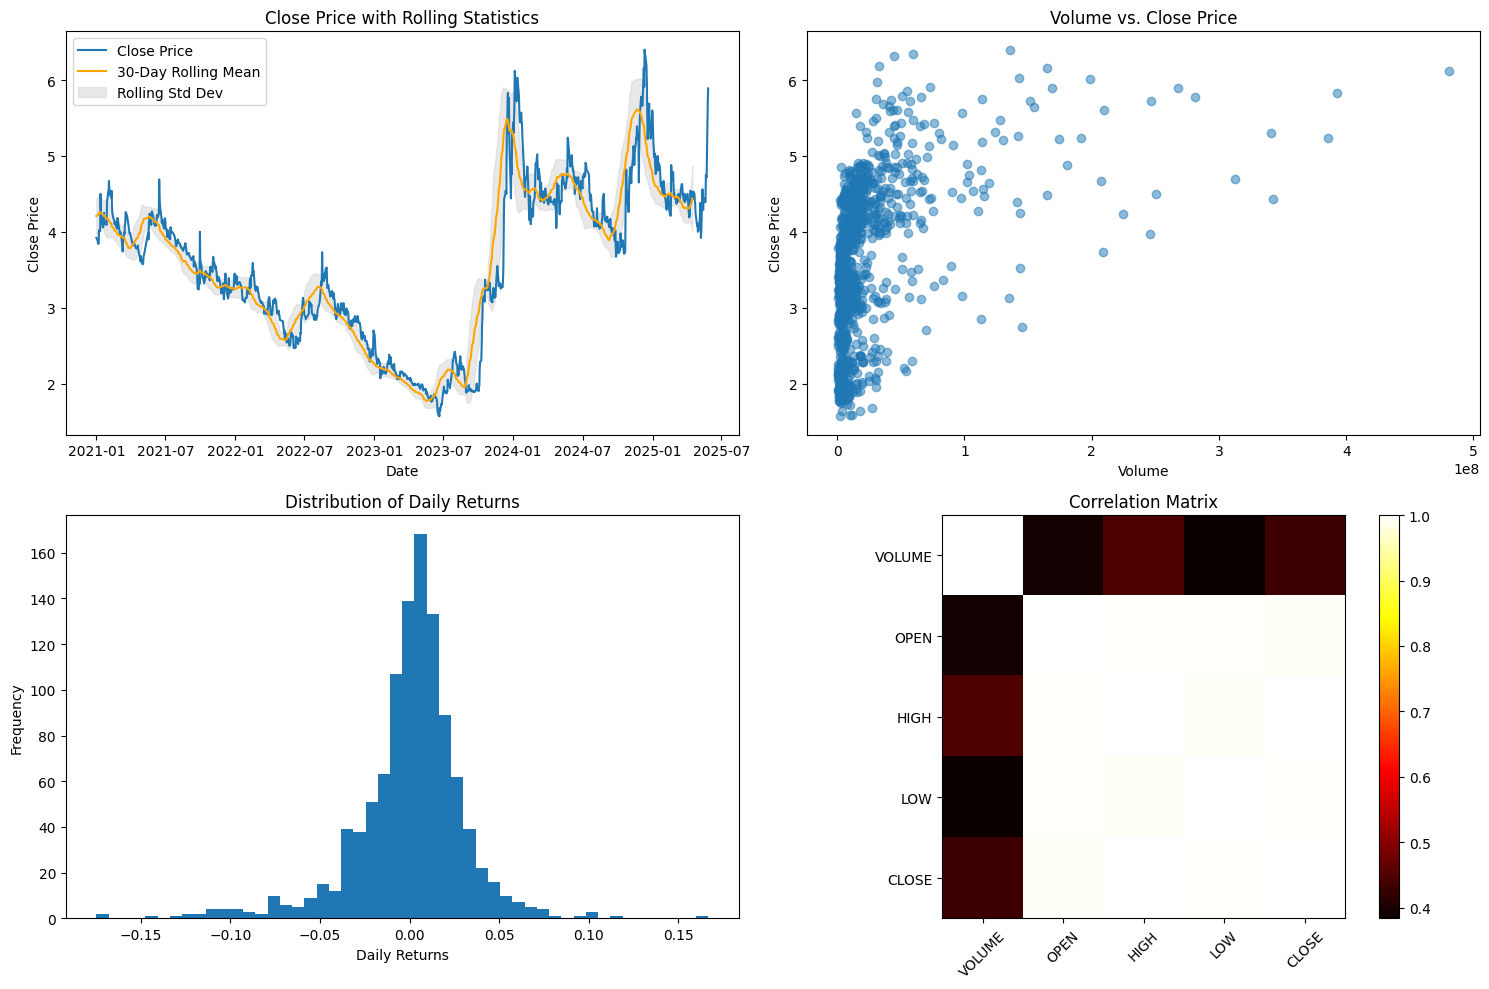

,VOLUME,OPEN,HIGH,LOW,CLOSE
VOLUME,1.000000,0.393986,0.445422,0.383627,0.431399
OPEN,0.393986,1.000000,0.995591,0.996867,0.993659
HIGH,0.445422,0.995591,1.000000,0.994840,0.997954
LOW,0.383627,0.996867,0.994840,1.000000,0.996445
CLOSE,0.431399,0.993659,0.997954,0.996445,1.000000


,DATE,OPEN,HIGH,LOW,CLOSE,VOLUME,CLOSE_ROLLING_MEAN,CLOSE_ROLLING_STD,DAILY_RETURNS
count,1082,1082.000000,1082.000000,1082.000000,1082.000000,1.082000e+03,1053.000000,1053.000000,1081.000000
mean,2023-03-17 09:28:16.857671168,3.576340,3.655323,3.491830,3.560878,2.251180e+07,3.539693,0.205731,0.000114
min,2021-01-01 00:00:00,1.600000,1.610000,1.550000,1.570000,3.100640e+05,1.771333,0.037226,-0.174825
25%,2022-02-09 06:00:00,2.850000,2.890000,2.802500,2.840000,3.883569e+06,2.787000,0.111291,-0.011080
50%,2023-03-11 12:00:00,3.550000,3.625000,3.480000,3.545000,8.886202e+06,3.468333,0.155312,0.003425
75%,2024-04-21 06:00:00,4.380000,4.487500,4.267500,4.370000,2.081525e+07,4.387333,0.227505,0.015873
max,2025-05-27 00:00:00,6.510000,6.590000,6.250000,6.400000,4.811199e+08,5.615667,0.952204,0.166667
std,NaN,1.030551,1.060277,0.995182,1.023811,4.294844e+07,0.994849,0.156356,0.030972


In [ ]:
import matplotlib.pyplot as plt

# Calculate rolling statistics for stock prices
df['CLOSE_ROLLING_MEAN'] = df['CLOSE'].rolling(window=30).mean()
df['CLOSE_ROLLING_STD'] = df['CLOSE'].rolling(window=30).std()

# Calculate correlation between volume and prices
correlation = df[['VOLUME', 'OPEN', 'HIGH', 'LOW', 'CLOSE']].corr()

# Calculate daily returns
df['DAILY_RETURNS'] = df['CLOSE'].pct_change()

# Plotting
plt.figure(figsize=(15, 10))

# Plot stock prices with rolling mean
plt.subplot(2, 2, 1)
plt.plot(df['DATE'], df['CLOSE'], label='Close Price')
plt.plot(df['DATE'], df['CLOSE_ROLLING_MEAN'], label='30-Day Rolling Mean', color='orange')
plt.fill_between(df['DATE'], df['CLOSE_ROLLING_MEAN'] - df['CLOSE_ROLLING_STD'], df['CLOSE_ROLLING_MEAN'] + df['CLOSE_ROLLING_STD'], color='lightgray', alpha=0.5, label='Rolling Std Dev')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Close Price with Rolling Statistics')
plt.legend()


# Plot volume vs. close price
plt.subplot(2, 2, 2)
plt.scatter(df['VOLUME'], df['CLOSE'], alpha=0.5)
plt.xlabel('Volume')
plt.ylabel('Close Price')
plt.title('Volume vs. Close Price')


# Plot the distribution of daily returns
plt.subplot(2, 2, 3)
plt.hist(df['DAILY_RETURNS'].dropna(), bins=50)
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Returns')

# Display correlation matrix
plt.subplot(2, 2, 4)
plt.imshow(correlation, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

display(correlation)
display(df.describe())

## Data visualization

### Subtask:
Visualize the stock data to identify trends, patterns, and potential outliers.


**Reasoning**:
Generate the required plots to visualize trends, patterns, and potential outliers in the stock data.



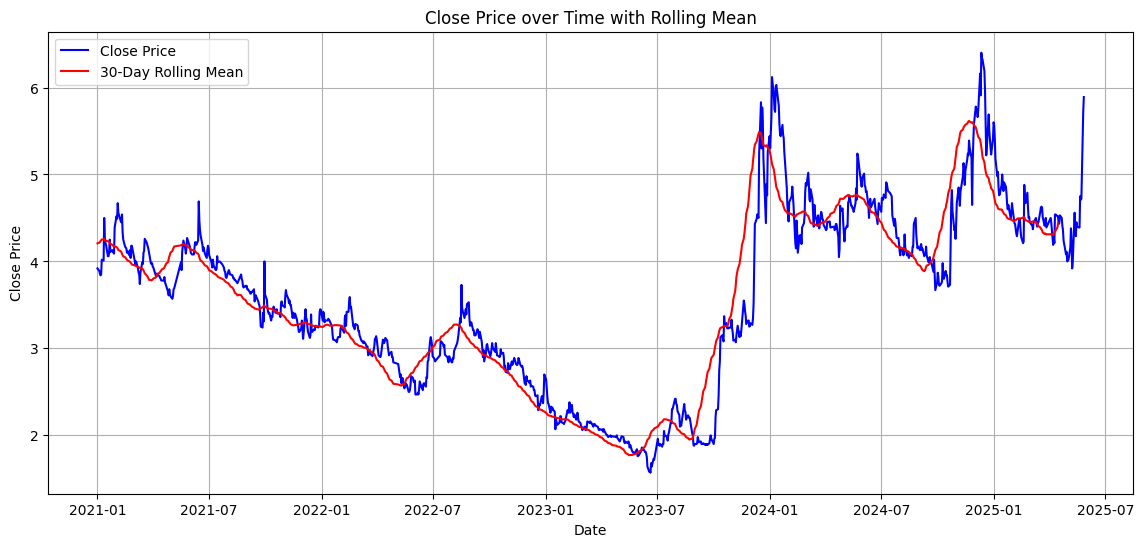

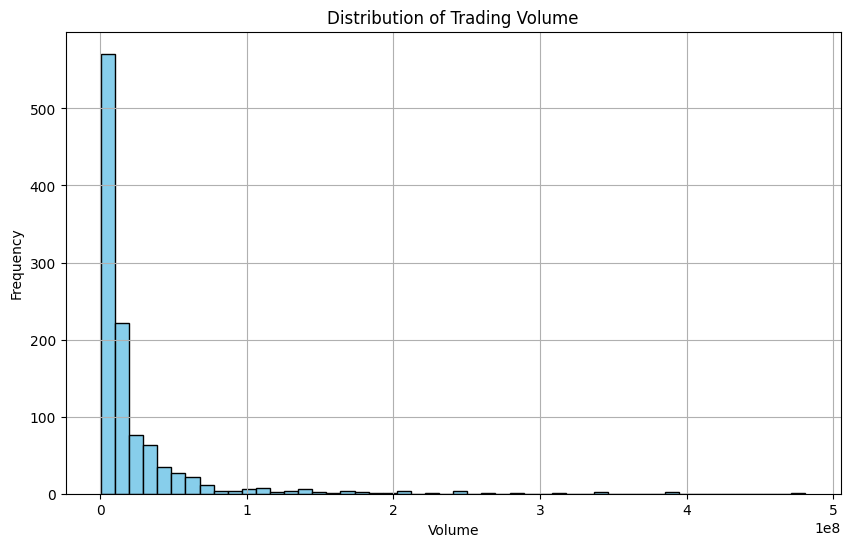

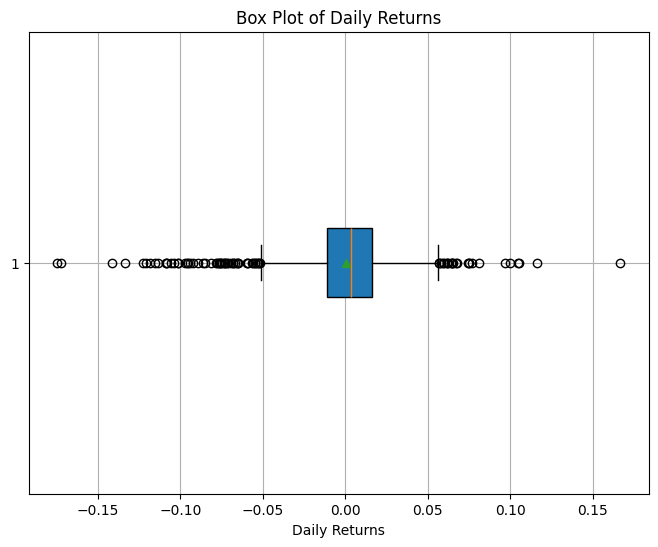

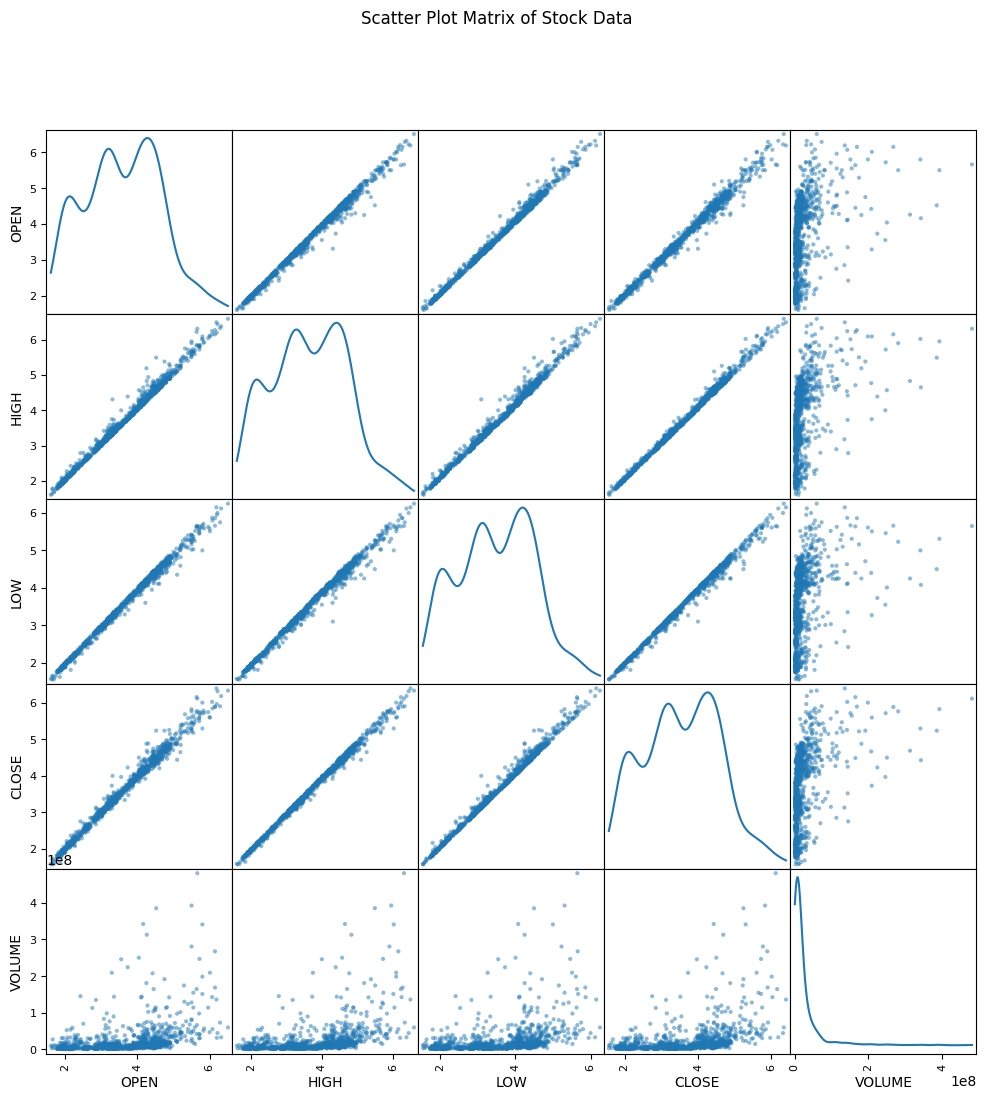

In [ ]:
import matplotlib.pyplot as plt

# Create a line plot of the 'CLOSE' price over time
plt.figure(figsize=(14, 6))
plt.plot(df['DATE'], df['CLOSE'], label='Close Price', color='blue')
plt.plot(df['DATE'], df['CLOSE_ROLLING_MEAN'], label='30-Day Rolling Mean', color='red')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Close Price over Time with Rolling Mean')
plt.legend()
plt.grid(True)
plt.show()

# Generate a histogram of the 'VOLUME' column
plt.figure(figsize=(10, 6))
plt.hist(df['VOLUME'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.title('Distribution of Trading Volume')
plt.grid(True)
plt.show()

# Create a box plot of the 'DAILY_RETURNS'
plt.figure(figsize=(8, 6))
plt.boxplot(df['DAILY_RETURNS'].dropna(), vert=False, patch_artist=True, showmeans=True)
plt.xlabel('Daily Returns')
plt.title('Box Plot of Daily Returns')
plt.grid(True)
plt.show()

# Generate a scatter plot matrix (optional but recommended)
from pandas.plotting import scatter_matrix
scatter_matrix(df[['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME']], alpha=0.5, figsize=(12, 12), diagonal='kde')
plt.suptitle('Scatter Plot Matrix of Stock Data')
plt.show()

## Summary:

### Q&A
No questions were asked in the provided task.

### Data Analysis Key Findings
* The dataset contains stock market data from 2021 to 2025, with daily records of open, high, low, close prices, and volume.
* No missing values were found in the dataset.
* The 'VOLUME' column exhibits a large maximum value compared to other percentiles, suggesting potential outliers or high trading volume events.
* The 'DATE' column has some non-consecutive dates, with gaps of up to 11 days between records.
* Rolling mean and standard deviation calculations on closing prices reveal trends and volatility over time.
* Correlation analysis shows relationships between trading volume and price variables.
* Daily returns were calculated and visualized to identify periods of high volatility, showing the distribution of price changes.
* Visualizations, including line plots, histograms, box plots, and scatter plots, further illustrate trends, patterns, and potential outliers.


### Insights or Next Steps
* Investigate the reasons for the non-consecutive dates in the dataset.  Are there any specific events or data collection issues that might explain the gaps?
* Analyze the identified high trading volume events to understand their potential causes and impact on stock price movements.
* Further explore the correlation between trading volume and price to identify potential trading opportunities or patterns.


In [ ]:
import pandas as pd

# Load Excel
file_path = 'KEL 2021 - 2025 Stock Rate Data.xlsx'
df = pd.read_excel(file_path)

# Convert DATE to datetime
df['DATE'] = pd.to_datetime(df['DATE'])

# Sort by date (ascending)
df = df.sort_values('DATE').reset_index(drop=True)

# Filter needed columns
df = df[['DATE', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME']]


In [ ]:
pip install plotly


In [5]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(x=df['DATE'],
                open=df['OPEN'],
                high=df['HIGH'],
                low=df['LOW'],
                close=df['CLOSE'])])

fig.update_layout(title='KEL Stock Candlestick Chart (2021–2025)',
                  xaxis_title='Date', yaxis_title='Price (PKR)')
fig.show()


In [6]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Use only closing price
data = df[['DATE', 'CLOSE']]
data.set_index('DATE', inplace=True)

# Normalize
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create sequences (e.g., 60-day lookback)
lookback = 1500
X, y = [], []

for i in range(lookback, len(scaled_data)):
    X.append(scaled_data[i-lookback:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))


IndexError: tuple index out of range

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, y, epochs=20, batch_size=32)


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.0858
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0046
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0033
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0027
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0029
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0024
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0022
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0025
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0019
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0019
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0019
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0019
Epoch 13/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0019
Epoch 14/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0017
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0021
Epoch 16/20
32/

In [ ]:
last_60 = scaled_data[-60:]
future_preds = []

for i in range(3):  # Extend this to predict 3 key dates
    pred_input = last_60[-60:].reshape(1, 60, 1)
    pred = model.predict(pred_input)
    future_preds.append(pred[0][0])
    last_60 = np.append(last_60, pred).reshape(-1, 1)

# Inverse transform to get actual prices
predicted_prices = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1))
print("Predicted Prices:", predicted_prices)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Predicted Prices: [[5.1300664]
 [5.277938 ]
 [5.358521 ]]


In [ ]:
initial_price = predicted_prices[0][0]
investment = 10000
shares = investment / initial_price

for i, price in enumerate(predicted_prices):
    value = shares * price[0]
    print(f"Investment Value at Future Date {i+1}: PKR {value:.2f}")


Investment Value at Future Date 1: PKR 10000.00
Investment Value at Future Date 2: PKR 10288.25
Investment Value at Future Date 3: PKR 10445.32


In [7]:
# Step 1: Install Tesseract OCR and required libs
!sudo apt-get install -y tesseract-ocr
!pip install pytesseract

# Step 2: Upload your image
from google.colab import files
uploaded = files.upload()

# Step 3: Import libs and load image
from PIL import Image
import pytesseract
import io

# Get the uploaded image filename (first uploaded file)
filename = list(uploaded.keys())[0]

# Open the image with PIL
image = Image.open(io.BytesIO(uploaded[filename]))

# Display the image (optional)
image.show()

# Step 4: Extract text using pytesseract OCR
text = pytesseract.image_to_string(image)
print("Extracted Text:\n", text)

# Step 5: (Optional) Now you need to parse the 'text' variable to find your OHLC prices,
# for example using regex or string operations depending on how the text looks.

# Example dummy parsing (replace with your actual parsing logic):
import re

# Let's say you want to find all prices like decimal numbers
prices = re.findall(r"\d+\.\d+", text)
print("Prices found in text:", prices)

# You can convert prices to floats and construct your data arrays for prediction
prices = list(map(float, prices))
print("Prices as floats:", prices)


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


Saving Screenshot 2025-05-29 200955.png to Screenshot 2025-05-29 200955.png
Extracted Text:
  

DATE OPEN HIGH Low CLOSE VOLUME
Nov 30, 2023 3.39 3.40 3.21 3.26 8,891,918
Nov 29, 2023 3.30 3.37 3.24 3.25 7,861,342
Nov 28, 2023 3.31 3.44 3.30 3.32 11,713,168
Nov 27, 2023 3.28 3.34 3.26 3.32 6,304,504
Nov 24, 2023 3.39 3.44 3.26 3.28 16,748,465
Nov 23, 2023 3.50 3.52 3.35 3.38 18,306,325
Nov 22, 2023 3.46 3.57 3.40 3.43 19,602,441
Nov 21, 2023 3.60 3.69 3.48 3.51 63,355,766
Nov 20, 2023 3.34 3.60 3.34 3.55 89,794,643
Nov 17, 2023 3.23 3.48 3.23 3.29 76,300,648
Nov 16, 2023 3.20 3.22 3.11 3.21 13,197,760
Nov 15, 2023 3.15, 3.23 3.11 3.14 14,915,857
Nov 14, 2023 3.14 3.21 3.04 3.19 9,045,379
Nov 13, 2023 3.22 3.29 3.12 3.13 7,706,958

Prices found in text: ['3.39', '3.40', '3.21', '3.26', '3.30', '3.37', '3.24', '3.25', '3.31', '3.44', '3.30', '3.32', '3.28', '3.34', '3.26', '3.32', '3.39', '3.44', '3.26', '3.28', '3.50', '3.52', '3.35', '3.38', '3.46', '3.57', '3.40', '3.43', '3.60', '3.